In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "img"
os.makedirs(OUT_DIR, exist_ok=True)

TAU = 0.02  # безразмерный шаг по времени, согласован с relax.py
US = (0.5, 1.0, 1.5)
COLORS = {0.5: "tab:blue", 1.0: "tab:purple", 1.5: "tab:red"}


def unpack_quarter(f_q, N=None):
    """Разворачивает (N, N//2, N//2) обратно в (N, N, N) по симметриям y, z.
    Используется для снимков, сохранённых relax.py в виде четверти (см. #6 в правки.md)."""
    if N is None:
        N = f_q.shape[1] * 2
    h = N // 2
    f = np.empty((f_q.shape[0], N, N), dtype=np.float64)
    f[:, h:, h:] = f_q
    f[:, :h, h:] = f_q[:, ::-1, :]
    f[:, h:, :h] = f_q[:, :, ::-1]
    f[:, :h, :h] = f_q[:, ::-1, ::-1]
    return f


def get_snap(npz, key):
    """Возвращает полный массив f (N, N, N) из снимка, автоматически распаковывая
    из четверти, если файл .npz сохранён с quarter_storage=True."""
    arr = npz[key]
    is_quarter = bool(npz["quarter_storage"]) if "quarter_storage" in npz.files else False
    if is_quarter or (arr.ndim == 3 and arr.shape[0] != arr.shape[1]):
        return unpack_quarter(arr)
    return arr

In [2]:
# Загрузка макропараметров: T, T_xx, H для трёх значений u
def tag(u):
    return f"{int(round(u * 10)):02d}"

data = {}
for u in US:
    arr = np.loadtxt(f"{tag(u)}.out")
    data[u] = {
        "T": arr[:, 0],
        "T_xx": arr[:, 1],
        "H": arr[:, 2],
    }

n_steps = len(data[US[0]]["T"])
t = np.arange(n_steps) * TAU
print(f"Загружено: {n_steps} шагов на каждое u, t_max = {t[-1]:.2f}")

Загружено: 1000 шагов на каждое u, t_max = 19.98


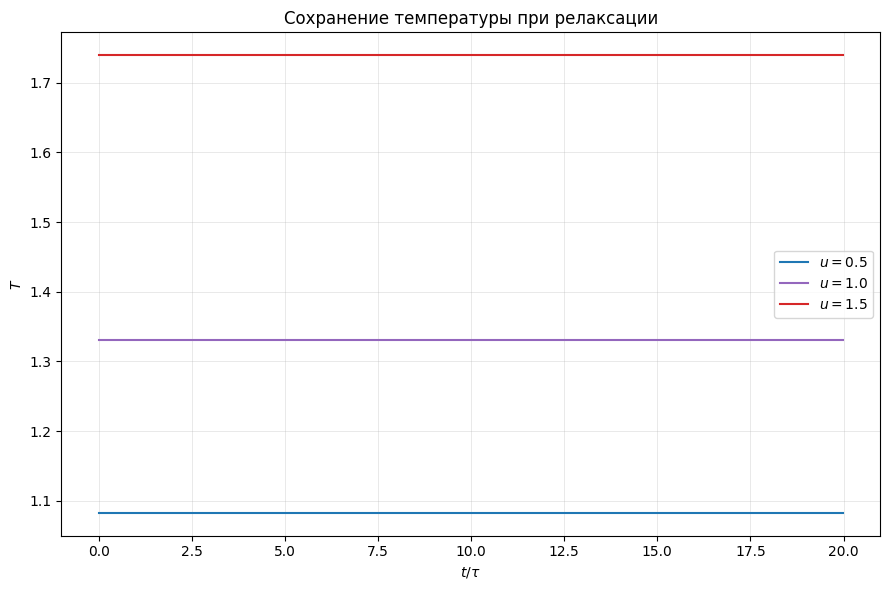

In [3]:
# Температура T(t) — должна сохраняться (тест на консервативность)
fig, ax = plt.subplots(figsize=(9, 6))
for u in US:
    ax.plot(t, data[u]["T"], "-", color=COLORS[u], label=fr"$u={u}$")
ax.set_xlabel(r"$t/\tau$")
ax.set_ylabel(r"$T$")
ax.set_title("Сохранение температуры при релаксации")
ax.grid(True, alpha=0.4)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "T_combined.png"), dpi=150)
plt.show()

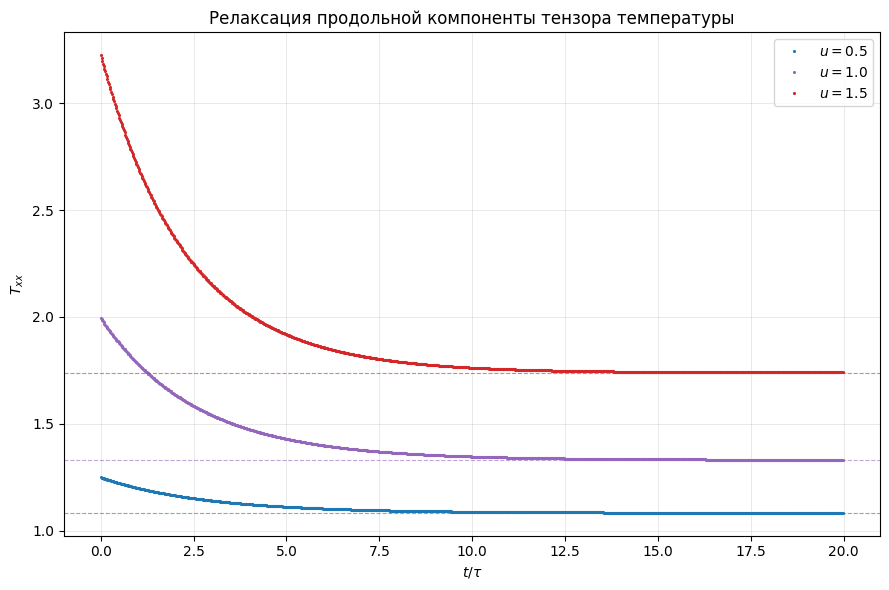

In [4]:
# T_xx(t) — главный график: продольная компонента релаксирует к T
fig, ax = plt.subplots(figsize=(9, 6))
for u in US:
    ax.plot(t, data[u]["T_xx"], ".", ms=2.5, color=COLORS[u], label=fr"$u={u}$")
    T_eq = data[u]["T"].mean()
    ax.axhline(T_eq, color=COLORS[u], ls="--", lw=0.8, alpha=0.6)
ax.set_xlabel(r"$t/\tau$")
ax.set_ylabel(r"$T_{xx}$")
ax.set_title(r"Релаксация продольной компоненты тензора температуры")
ax.grid(True, alpha=0.4)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "Txx_combined.png"), dpi=150)
plt.show()

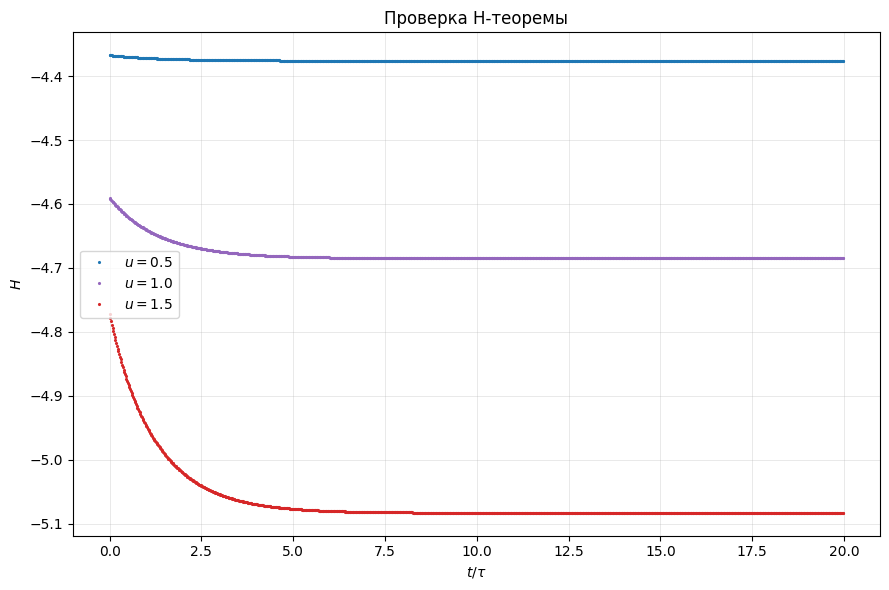

In [5]:
# H-функция Больцмана: убывает (Н-теорема)
fig, ax = plt.subplots(figsize=(9, 6))
for u in US:
    ax.plot(t, data[u]["H"], ".", ms=2.5, color=COLORS[u], label=fr"$u={u}$")
ax.set_xlabel(r"$t/\tau$")
ax.set_ylabel(r"$H$")
ax.set_title(r"Проверка Н-теоремы")
ax.grid(True, alpha=0.4)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "H_combined.png"), dpi=150)
plt.show()

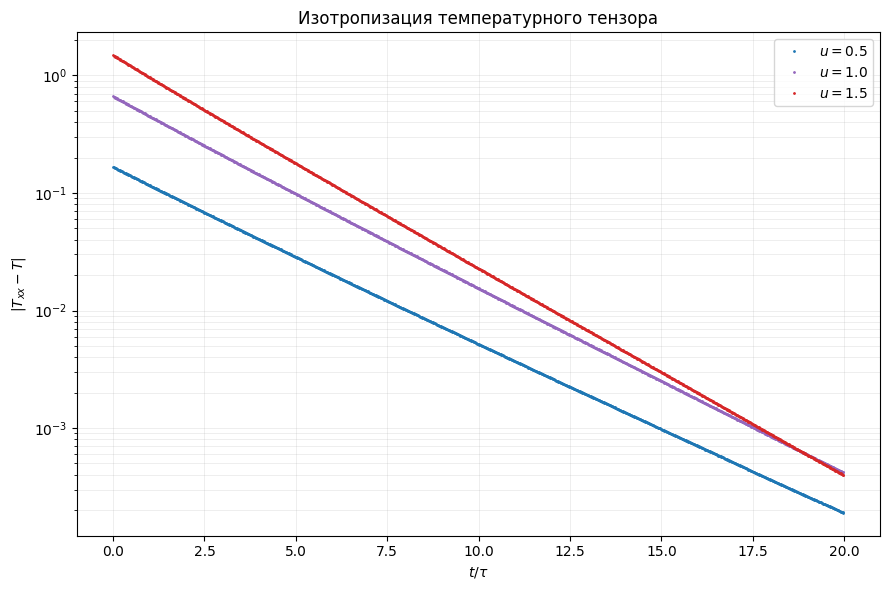

In [6]:
# Лог-график анизотропии |T_xx − T| — экспоненциальная релаксация
fig, ax = plt.subplots(figsize=(9, 6))
for u in US:
    diff = np.abs(data[u]["T_xx"] - data[u]["T"]) + 1e-12
    ax.semilogy(t, diff, ".", ms=2, color=COLORS[u], label=fr"$u={u}$")
ax.set_xlabel(r"$t/\tau$")
ax.set_ylabel(r"$|T_{xx} - T|$")
ax.set_title("Изотропизация температурного тензора")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "anisotropy_log.png"), dpi=150)
plt.show()

In [7]:
# Загрузка снимков функции распределения
SNAPS = {u: np.load(f"f_{tag(u)}.npz") for u in US}

# Список ключей снапшотов в правильном порядке.
# Фильтр: ровно "tNNNNN" (6 символов, NNNNN — индекс шага). Это исключает
# случайные ключи вроде "tau", "t00999_final" и т.п.
def snap_keys(npz):
    keys = [k for k in npz.files if len(k) == 6 and k[0] == "t" and k[1:].isdigit()]
    return sorted(keys, key=lambda k: int(k[1:]))

for u in US:
    keys = snap_keys(SNAPS[u])
    print(f"u={u}: снимки в моменты t = "
          f"{[round(int(k[1:]) * float(SNAPS[u]['tau']), 2) for k in keys]}")

u=0.5: снимки в моменты t = [0.0, 0.1, 0.3, 0.8, 2.0, 5.0, 10.0, 15.0, 19.98]
u=1.0: снимки в моменты t = [0.0, 0.1, 0.3, 0.8, 2.0, 5.0, 10.0, 15.0, 19.98]
u=1.5: снимки в моменты t = [0.0, 0.1, 0.3, 0.8, 2.0, 5.0, 10.0, 15.0, 19.98]


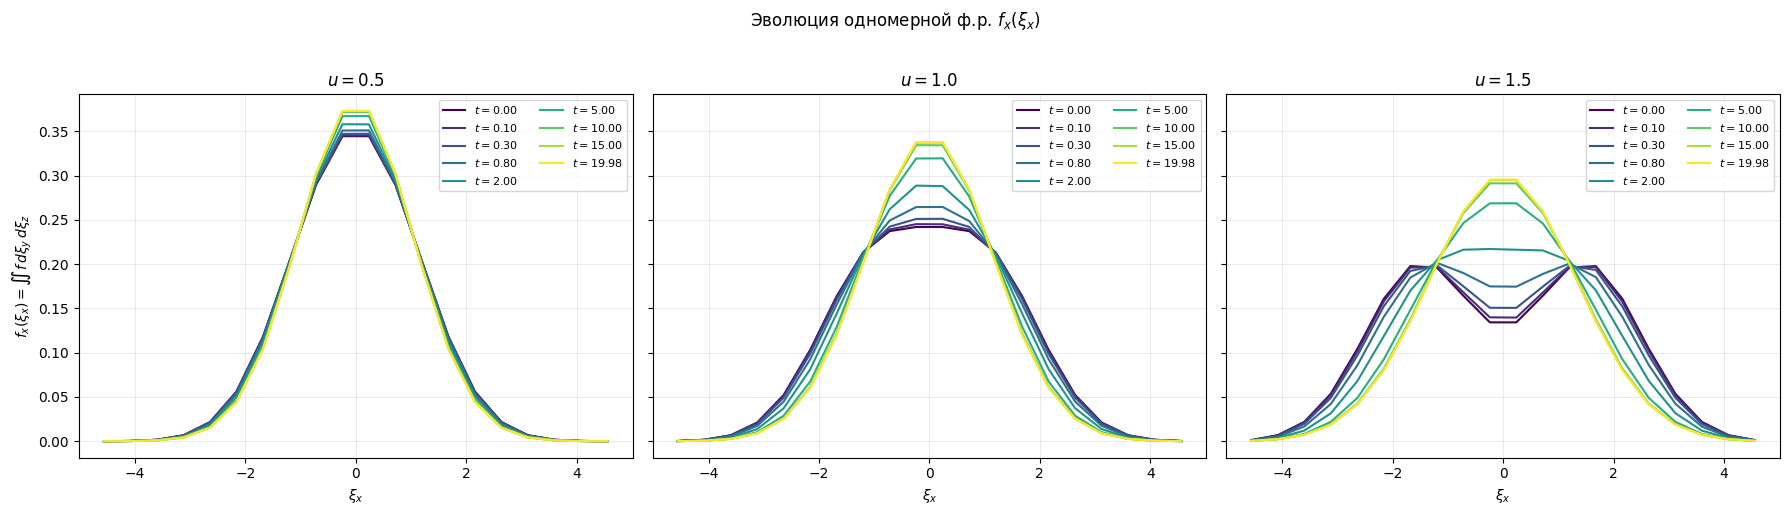

In [8]:
# Одномерная функция распределения f_x(ξ_x) = ∫∫ f dξ_y dξ_z
# в разные моменты времени (использует чётность по ξ_y, ξ_z — усредняет шум)
def reduced_fx(f3d, dxi):
    return f3d.sum(axis=(1, 2)) * (float(dxi[1]) * float(dxi[2]))


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, u in zip(axes, US):
    snap = SNAPS[u]
    xi_x = snap["xi_x"]
    dxi = snap["dxi"]
    keys = snap_keys(snap)
    cmap = plt.cm.viridis

    for i, k in enumerate(keys):
        f_full = get_snap(snap, k)             # автораспаковка четверти
        fx = reduced_fx(f_full, dxi)
        t_phys = int(k[1:]) * float(snap["tau"])
        color = cmap(i / max(len(keys) - 1, 1))
        ax.plot(xi_x, fx, color=color, lw=1.5, label=fr"$t={t_phys:.2f}$")

    ax.set_xlabel(r"$\xi_x$")
    if u == US[0]:
        ax.set_ylabel(r"$f_x(\xi_x) = \iint f\,d\xi_y\,d\xi_z$")
    ax.set_title(fr"$u={u}$")
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8, ncol=2, loc="upper right")

fig.suptitle(r"Эволюция одномерной ф.р. $f_x(\xi_x)$", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "f_marginal_evolution.png"), dpi=150, bbox_inches="tight")
plt.show()

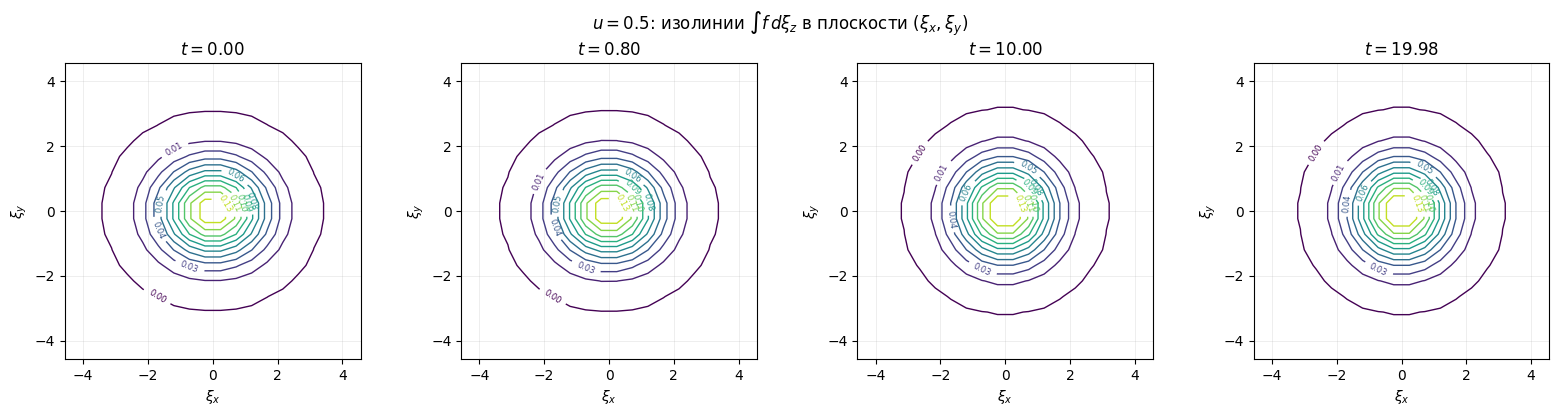

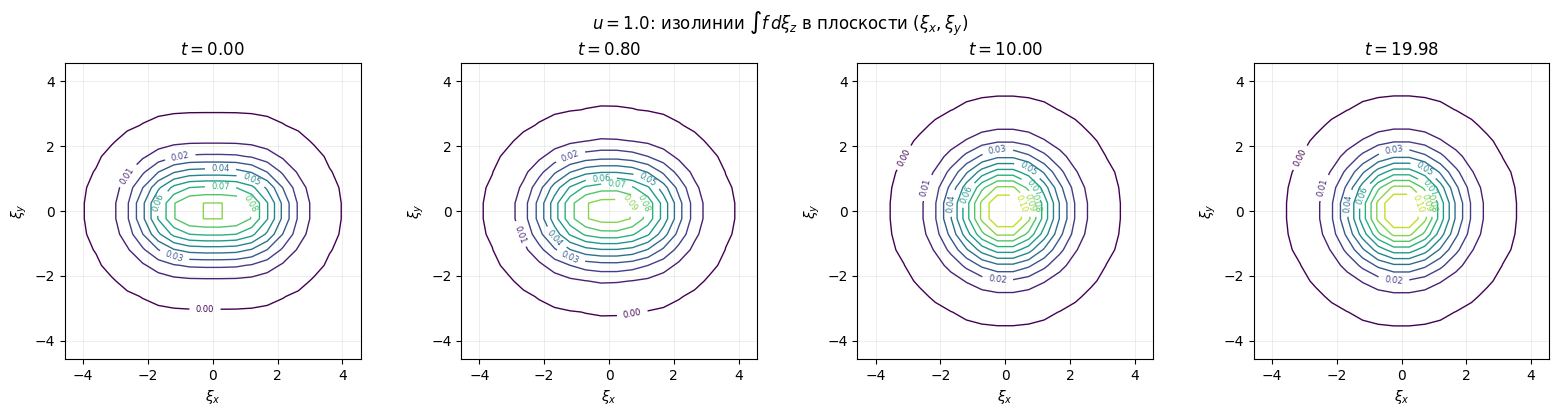

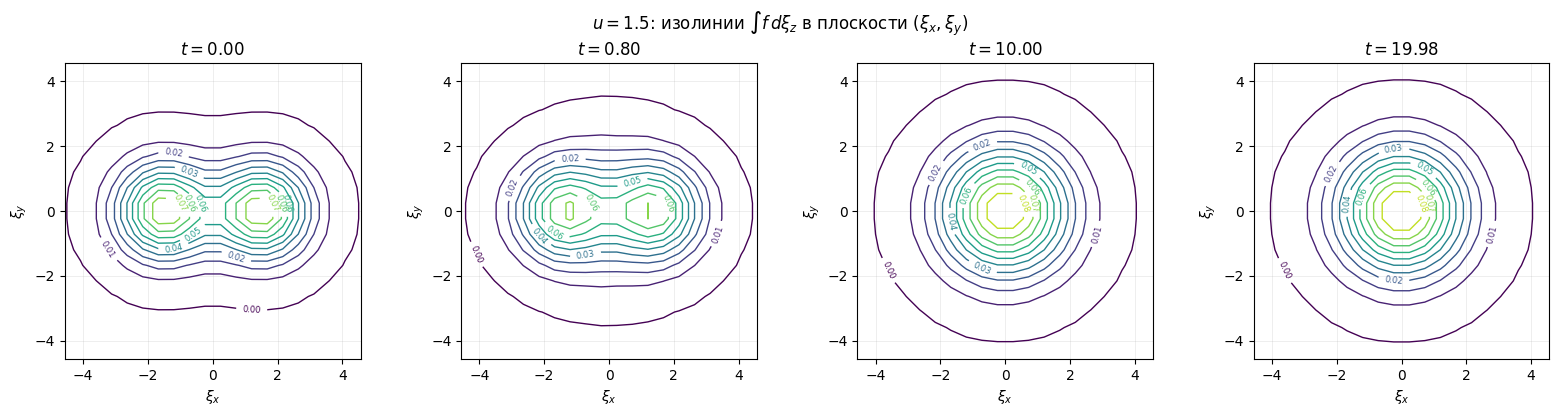

In [9]:
# Изолинии ∫f dξ_z в плоскости (ξ_x, ξ_y) — изотропизация
def reduced_fxy(f3d, dxi):
    return f3d.sum(axis=2) * float(dxi[2])


for u in US:
    snap = SNAPS[u]
    xi_x = snap["xi_x"]
    xi_y = snap["xi_y"]
    dxi = snap["dxi"]
    keys = snap_keys(snap)
    # выбираем 4 равномерно распределённых момента
    sel = [keys[0], keys[len(keys) // 3], keys[2 * len(keys) // 3], keys[-1]]
    fig, axes = plt.subplots(1, len(sel), figsize=(4 * len(sel), 4))

    fxy_all = [reduced_fxy(get_snap(snap, k), dxi) for k in sel]
    vmax = max(fxy.max() for fxy in fxy_all)
    levels = np.linspace(0.01 * vmax, vmax, 12)

    X, Y = np.meshgrid(xi_x, xi_y, indexing="ij")
    for ax, k, fxy in zip(axes, sel, fxy_all):
        t_phys = int(k[1:]) * float(snap["tau"])
        cs = ax.contour(X, Y, fxy, levels=levels, cmap="viridis",
                        linewidths=1.0)
        ax.clabel(cs, inline=True, fontsize=6, fmt="%.2f")
        ax.set_xlabel(r"$\xi_x$")
        ax.set_ylabel(r"$\xi_y$")
        ax.set_title(fr"$t={t_phys:.2f}$")
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)

    fig.suptitle(fr"$u={u}$: изолинии $\int f\,d\xi_z$ в плоскости $(\xi_x, \xi_y)$")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"f_xy_u{tag(u)}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

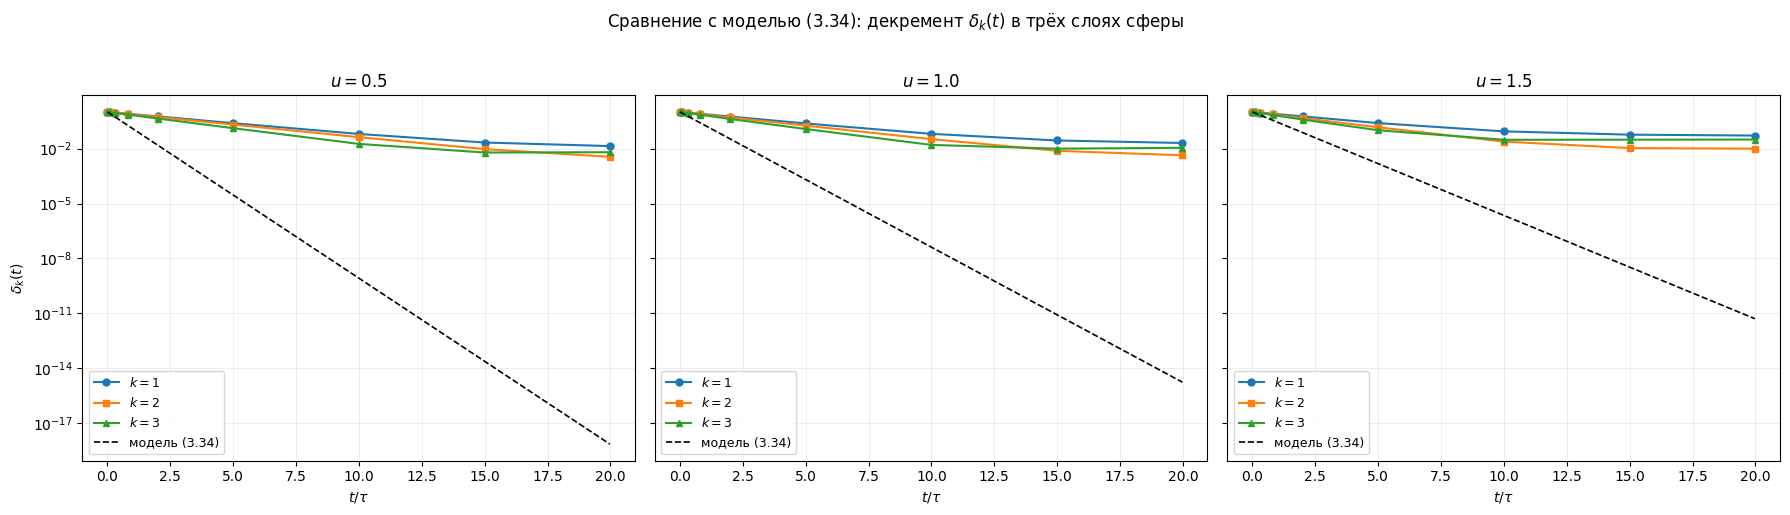

In [10]:
# Сравнение с релаксационным модельным уравнением (Пособие, формула 3.34, стр. 28).
# δ_k(t) = ||f - f_M||_k / ||f_0 - f_M||_k — нормированное отклонение от равновесного
# Максвелла в k-м слое сферы (k = 1, 2, 3; формула 3.38).
# Теоретический декремент: ln(δ) = -16 t / (5√2 T).
def maxwell_eq(xi_x, xi_y, xi_z, T_eq):
    """Равновесный максвеллиан с u=0 и температурой T_eq, нормированный на n=1."""
    X, Y, Z = np.meshgrid(xi_x, xi_y, xi_z, indexing="ij")
    f_M = np.exp(-(X**2 + Y**2 + Z**2) / (2 * T_eq)) / (2 * np.pi * T_eq) ** 1.5
    return f_M


def layer_norm(f_minus_fM, xi_x, xi_y, xi_z, dxi, k, xi_cut):
    """L2-норма разницы f - f_M в k-м слое сферы:
       (k-1) ξ_cut/3  ≤  |ξ|  <  k ξ_cut/3."""
    X, Y, Z = np.meshgrid(xi_x, xi_y, xi_z, indexing="ij")
    R = np.sqrt(X**2 + Y**2 + Z**2)
    mask = ((k - 1) * xi_cut / 3 <= R) & (R < k * xi_cut / 3)
    dV = float(dxi[0]) * float(dxi[1]) * float(dxi[2])
    return np.sqrt(np.sum((f_minus_fM[mask]) ** 2) * dV)


XI_CUT = 4.8

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, u in zip(axes, US):
    snap = SNAPS[u]
    xi_x, xi_y, xi_z = snap["xi_x"], snap["xi_y"], snap["xi_z"]
    dxi = snap["dxi"]
    keys = snap_keys(snap)
    T_eq = data[u]["T"].mean()
    f_M = maxwell_eq(xi_x, xi_y, xi_z, T_eq)

    times = np.array([int(k[1:]) * float(snap["tau"]) for k in keys])
    deltas = {1: [], 2: [], 3: []}
    norms_0 = {}

    for i, k_key in enumerate(keys):
        f_full = get_snap(snap, k_key)
        diff = f_full - f_M
        for k in (1, 2, 3):
            n = layer_norm(diff, xi_x, xi_y, xi_z, dxi, k, XI_CUT)
            if i == 0:
                norms_0[k] = n
            deltas[k].append(n / max(norms_0[k], 1e-30))

    for k, marker, c in [(1, "o", "tab:blue"), (2, "s", "tab:orange"), (3, "^", "tab:green")]:
        ax.semilogy(times, deltas[k], marker=marker, ls="-", color=c,
                    label=fr"$k={k}$", ms=5)

    # Теоретическая прямая Пособия (3.34): ln(δ) = -16 t / (5√2 T)
    t_grid = np.linspace(times.min(), times.max(), 100)
    ax.semilogy(t_grid, np.exp(-16 * t_grid / (5 * np.sqrt(2) * T_eq)),
                "k--", lw=1.2, label=r"модель (3.34)")

    ax.set_xlabel(r"$t/\tau$")
    if u == US[0]:
        ax.set_ylabel(r"$\delta_k(t)$")
    ax.set_title(fr"$u={u}$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle(r"Сравнение с моделью (3.34): декремент $\delta_k(t)$ в трёх слоях сферы", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "delta_k_evolution.png"), dpi=150, bbox_inches="tight")
plt.show()